<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Overfitting_Underfitting_Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overfitting & Underfitting in Machine Learning

This notebook demonstrates the core concepts of **underfitting**, **good fit**, and **overfitting**  
using the Diabetes dataset and polynomial regression — the canonical way to teach these ideas.

**Key concepts covered:**
- What underfitting and overfitting actually look like
- Train vs Test error as the diagnostic tool
- Learning curves for bias-variance diagnosis
- Validation curves for hyperparameter selection
- Regularisation (Ridge / Lasso) as a remedy for overfitting


## 1. Import Libraries

In [ ]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Scikit-learn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     learning_curve, validation_curve)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load & Explore the Diabetes Dataset

We use **one feature (`bmi`)** and the continuous target (disease progression).  
This keeps the plots simple and 2-D so the concepts are visually clear.


In [ ]:
diabetes = load_diabetes()
df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print("Shape:", df.shape)
print()
print(df[['bmi', 'target']].describe().round(2))
df.head()

Shape: (442, 11)

          bmi  target
count  442.00  442.00
mean    -0.00  152.13
std      0.05   77.09
min     -0.09   25.00
25%     -0.03   87.00
50%     -0.01  140.50
75%      0.03  211.50
max      0.17  346.00


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
# Use a single feature for 2-D visualisation
X = df[['bmi']].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 353
Test samples     : 89


## 3. The Core Diagnostic: Train Error vs Test Error

| Scenario | Train Error | Test Error | Verdict |
|---|---|---|---|
| **Underfitting** | High | High | Model is too simple — high bias |
| **Good fit** | Low | Low | Model generalises well |
| **Overfitting** | Very low | High | Model memorised training data — high variance |

We control model complexity through the **degree of the polynomial**.  
- Degree 1 → straight line → likely underfit  
- Degree ~3-5 → balanced  
- Degree 15+ → wiggly curve that memorises training noise → overfit


## 4. Underfitting — High Bias

A **degree-1 polynomial (plain linear regression)** is too rigid to capture  
even the gentle curve in the data. Both train and test errors are high.


In [ ]:
def make_poly_pipeline(degree):
    """Return a Pipeline: PolynomialFeatures -> LinearRegression."""
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

# Degree 1: Underfitting
pipe_underfit = make_poly_pipeline(degree=1)
pipe_underfit.fit(X_train, y_train)

train_r2 = pipe_underfit.score(X_train, y_train)
test_r2  = pipe_underfit.score(X_test,  y_test)
train_mse = mean_squared_error(y_train, pipe_underfit.predict(X_train))
test_mse  = mean_squared_error(y_test,  pipe_underfit.predict(X_test))

print("=== Degree-1 Polynomial (UNDERFIT) ===")
print(f"Train R²  : {train_r2:.4f}   |  Test R²  : {test_r2:.4f}")
print(f"Train MSE : {train_mse:.2f}  |  Test MSE : {test_mse:.2f}")
print()
print("Both train AND test R² are low → the model is too simple (underfitting)")

=== Degree-1 Polynomial (UNDERFIT) ===
Train R²  : 0.3657   |  Test R²  : 0.2334
Train MSE : 3854.11  |  Test MSE : 4061.83

Both train AND test R² are low → the model is too simple (underfitting).


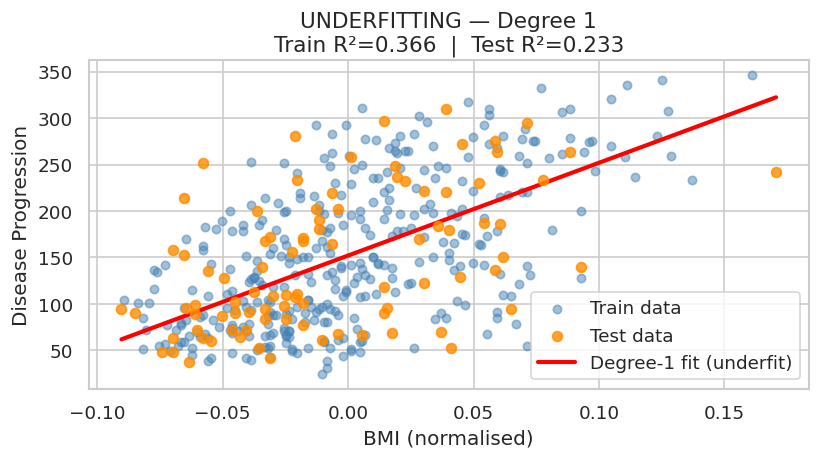

In [ ]:
# Plot
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_plot = pipe_underfit.predict(X_plot)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_train, y_train, alpha=0.5, label='Train data', color='steelblue', s=25)
ax.scatter(X_test,  y_test,  alpha=0.8, label='Test data',  color='darkorange', s=35, zorder=5)
ax.plot(X_plot, y_plot, color='red', linewidth=2.5, label='Degree-1 fit (underfit)')
ax.set_xlabel('BMI (normalised)')
ax.set_ylabel('Disease Progression')
ax.set_title(f'UNDERFITTING — Degree 1\nTrain R²={train_r2:.3f}  |  Test R²={test_r2:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Good Fit — Balanced Bias & Variance

A **degree-3 or degree-4 polynomial** captures the real trend without  
chasing noise. Train and test errors are both low and close to each other.


In [ ]:
pipe_good = make_poly_pipeline(degree=4)
pipe_good.fit(X_train, y_train)

train_r2 = pipe_good.score(X_train, y_train)
test_r2  = pipe_good.score(X_test,  y_test)
train_mse = mean_squared_error(y_train, pipe_good.predict(X_train))
test_mse  = mean_squared_error(y_test,  pipe_good.predict(X_test))

print("=== Degree-4 Polynomial (GOOD FIT) ===")
print(f"Train R²  : {train_r2:.4f}   |  Test R²  : {test_r2:.4f}")
print(f"Train MSE : {train_mse:.2f}  |  Test MSE : {test_mse:.2f}")
print()
print("Train and Test R² are both reasonable and close → good generalisation.")

=== Degree-4 Polynomial (GOOD FIT) ===
Train R²  : 0.3695   |  Test R²  : 0.2023
Train MSE : 3831.06  |  Test MSE : 4226.14

Train and Test R² are both reasonable and close → good generalisation.


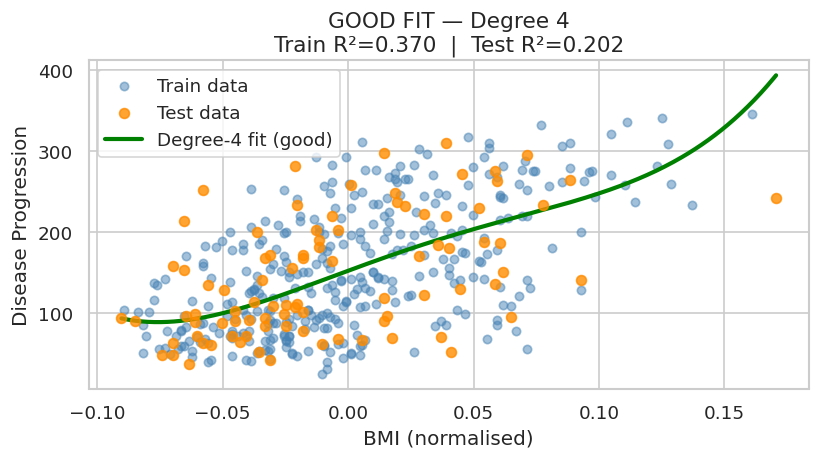

In [ ]:
y_plot_good = pipe_good.predict(X_plot)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_train, y_train, alpha=0.5, label='Train data', color='steelblue', s=25)
ax.scatter(X_test,  y_test,  alpha=0.8, label='Test data',  color='darkorange', s=35, zorder=5)
ax.plot(X_plot, y_plot_good, color='green', linewidth=2.5, label='Degree-4 fit (good)')
ax.set_xlabel('BMI (normalised)')
ax.set_ylabel('Disease Progression')
ax.set_title(f'GOOD FIT — Degree 4\nTrain R²={train_r2:.3f}  |  Test R²={test_r2:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Overfitting — High Variance

A **degree-15 polynomial** has so many parameters it can memorise every  
training point. Train error drops close to 0, but test error shoots up.  
The curve wiggles wildly through noise — this is overfitting.


In [ ]:
pipe_overfit = make_poly_pipeline(degree=15)
pipe_overfit.fit(X_train, y_train)

train_r2 = pipe_overfit.score(X_train, y_train)
test_r2  = pipe_overfit.score(X_test,  y_test)
train_mse = mean_squared_error(y_train, pipe_overfit.predict(X_train))
test_mse  = mean_squared_error(y_test,  pipe_overfit.predict(X_test))

print("=== Degree-15 Polynomial (OVERFIT) ===")
print(f"Train R²  : {train_r2:.4f}   |  Test R²  : {test_r2:.4f}")
print(f"Train MSE : {train_mse:.2f}  |  Test MSE : {test_mse:.2f}")
print()
print("Train R² is very high but Test R² is much lower → the model has overfit.")

=== Degree-15 Polynomial (OVERFIT) ===
Train R²  : 0.3918   |  Test R²  : -341.7145
Train MSE : 3695.95  |  Test MSE : 1815753.37

Train R² is very high but Test R² is much lower → the model has overfit.


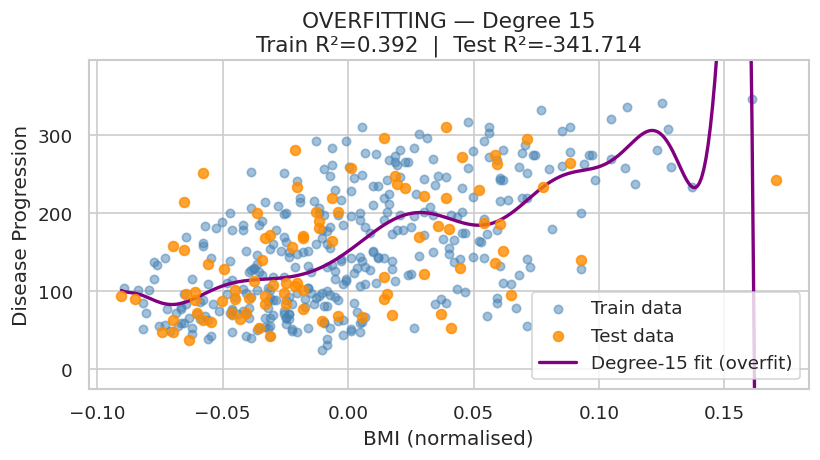

In [ ]:
y_plot_over = pipe_overfit.predict(X_plot)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_train, y_train, alpha=0.5, label='Train data', color='steelblue', s=25)
ax.scatter(X_test,  y_test,  alpha=0.8, label='Test data',  color='darkorange', s=35, zorder=5)
ax.plot(X_plot, y_plot_over, color='purple', linewidth=2, label='Degree-15 fit (overfit)')
ax.set_ylim(y.min() - 50, y.max() + 50)
ax.set_xlabel('BMI (normalised)')
ax.set_ylabel('Disease Progression')
ax.set_title(f'OVERFITTING — Degree 15\nTrain R²={train_r2:.3f}  |  Test R²={test_r2:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Side-by-Side Comparison

Three models, one figure — the clearest way to see all three regimes at once.


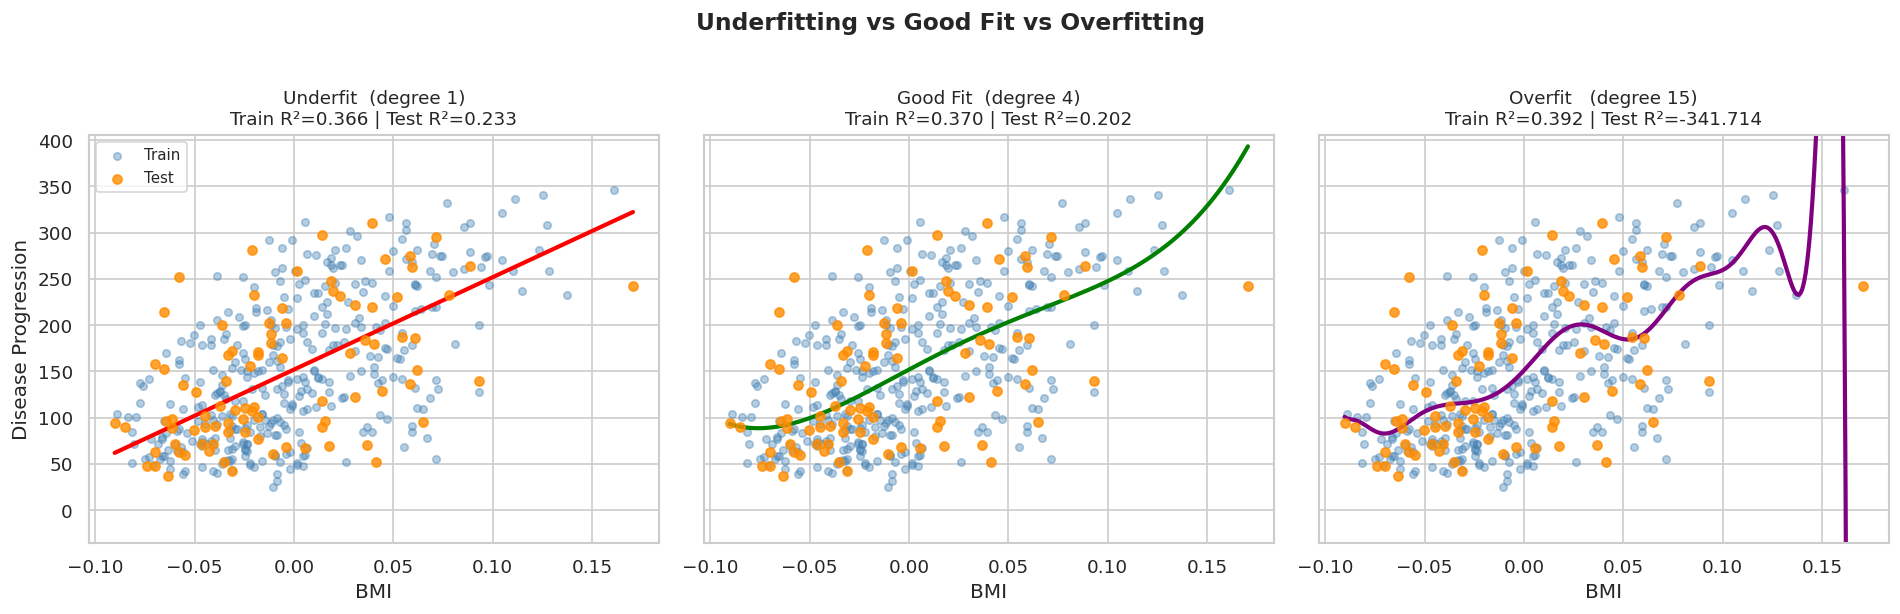

In [ ]:
models_info = [
    (pipe_underfit, 1,  'red',    'Underfit  (degree 1)'),
    (pipe_good,     4,  'green',  'Good Fit  (degree 4)'),
    (pipe_overfit,  15, 'purple', 'Overfit   (degree 15)'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (pipe, deg, color, label) in zip(axes, models_info):
    tr2 = pipe.score(X_train, y_train)
    te2 = pipe.score(X_test,  y_test)
    yp  = pipe.predict(X_plot)

    ax.scatter(X_train, y_train, alpha=0.4, color='steelblue', s=20, label='Train')
    ax.scatter(X_test,  y_test,  alpha=0.8, color='darkorange', s=30, zorder=5, label='Test')
    ax.plot(X_plot, yp, color=color, linewidth=2.5)
    ax.set_ylim(y.min() - 60, y.max() + 60)
    ax.set_title(f'{label}\nTrain R²={tr2:.3f} | Test R²={te2:.3f}', fontsize=11)
    ax.set_xlabel('BMI')
    if ax == axes[0]:
        ax.set_ylabel('Disease Progression')
        ax.legend(fontsize=9)

plt.suptitle('Underfitting vs Good Fit vs Overfitting', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 8. Model Complexity Curve

The **golden diagnostic**: plot Train error and Test error against model complexity.

- Where Test error is **decreasing** → still underfitting  
- Where Test error is **at its minimum** → sweet spot  
- Where Test error is **increasing** while Train error keeps falling → overfitting


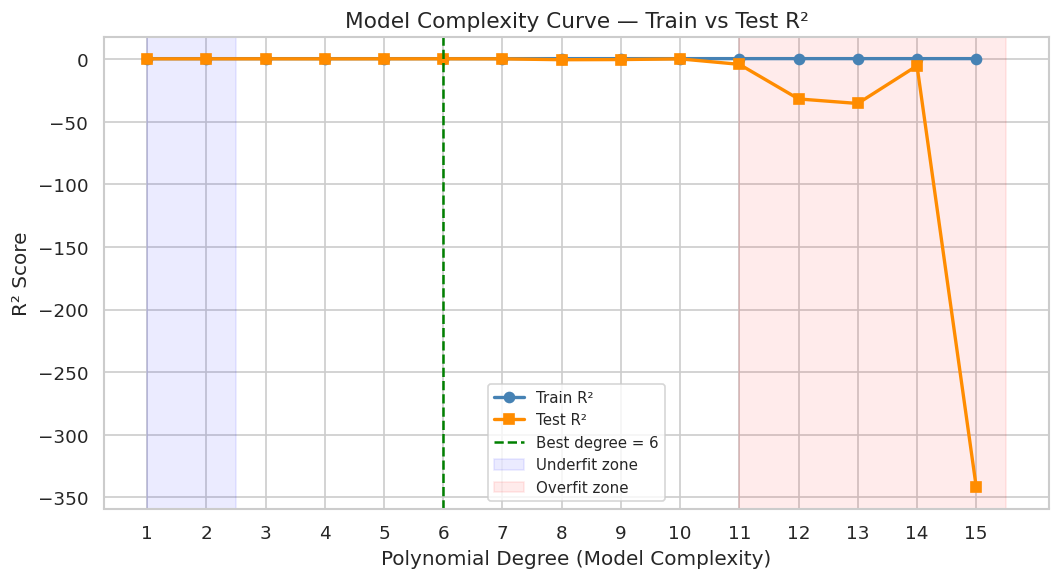

Best polynomial degree (by Test R²): 6


In [ ]:
degrees = range(1, 16)
train_r2_scores, test_r2_scores = [], []

for d in degrees:
    pipe = make_poly_pipeline(degree=d)
    pipe.fit(X_train, y_train)
    train_r2_scores.append(pipe.score(X_train, y_train))
    test_r2_scores.append(pipe.score(X_test,  y_test))

best_deg = degrees[np.argmax(test_r2_scores)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(degrees, train_r2_scores, 'o-', color='steelblue',  label='Train R²', linewidth=2)
ax.plot(degrees, test_r2_scores,  's-', color='darkorange', label='Test R²',  linewidth=2)
ax.axvline(best_deg, color='green', linestyle='--', linewidth=1.5,
           label=f'Best degree = {best_deg}')
ax.axvspan(1, 2.5,  alpha=0.08, color='blue',   label='Underfit zone')
ax.axvspan(11, 15.5, alpha=0.08, color='red',    label='Overfit zone')
ax.set_xlabel('Polynomial Degree (Model Complexity)', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Model Complexity Curve — Train vs Test R²', fontsize=13)
ax.legend(fontsize=9)
ax.set_xticks(list(degrees))
plt.tight_layout()
plt.show()

print(f"Best polynomial degree (by Test R²): {best_deg}")


## 9. Learning Curves — Another Key Diagnostic

A **learning curve** shows how Train and Validation error change as we add more  
training data. This reveals whether the problem is high bias or high variance.

| Pattern | Diagnosis |
|---|---|
| Both curves converge at a **high** error | Underfitting (need more complex model) |
| Both curves converge at a **low** error  | Good fit |
| Large **gap** between train and val even with lots of data | Overfitting (need regularisation or more data) |


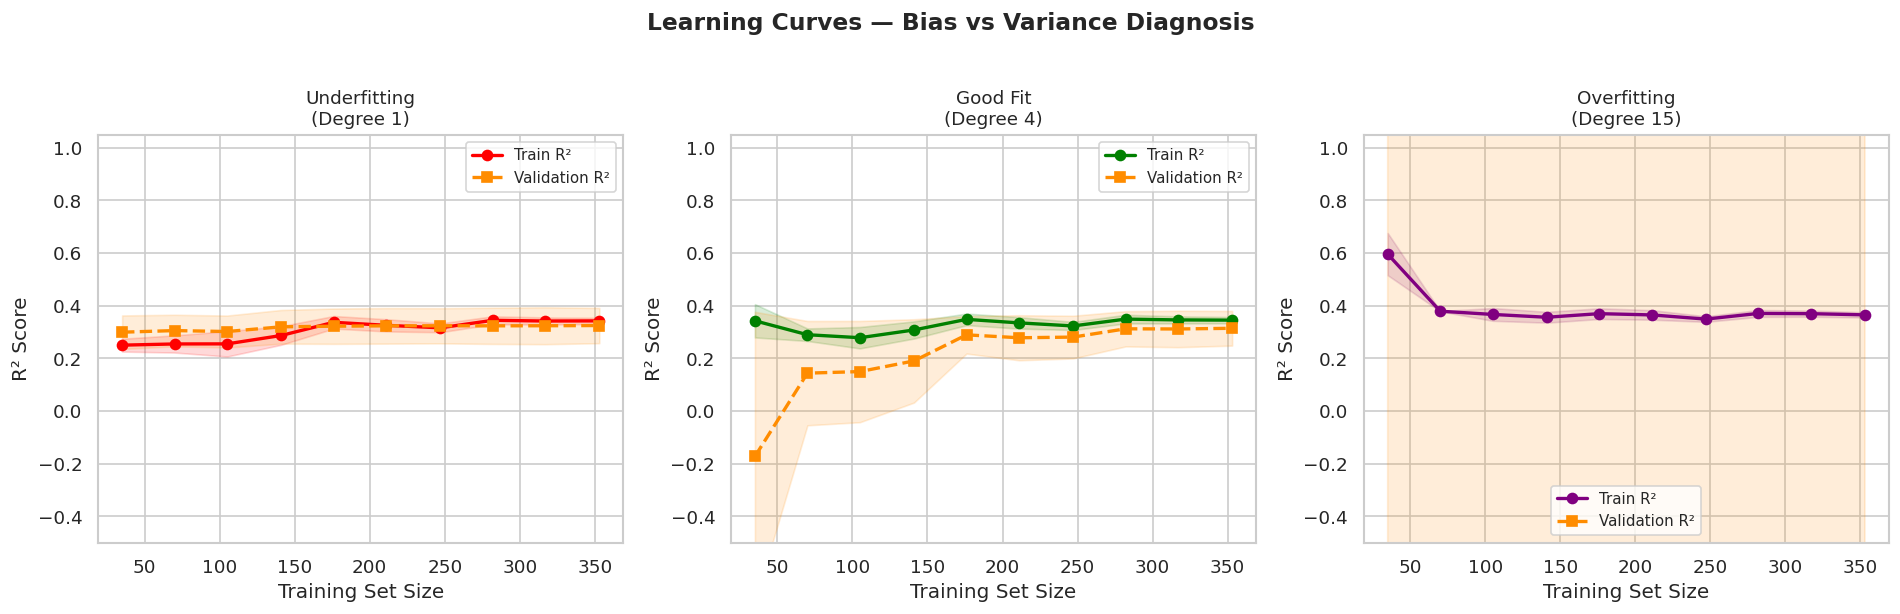

In [ ]:
def plot_learning_curve(estimator, title, X, y, ax, cv=5, color='steelblue'):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2', n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color=color,    label='Train R²',      linewidth=2)
    ax.plot(train_sizes, val_mean,   's--', color='darkorange', label='Validation R²', linewidth=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=color)
    ax.fill_between(train_sizes, val_mean - val_std,   val_mean + val_std,   alpha=0.15, color='darkorange')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('R² Score')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.5, 1.05)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_learning_curve(make_poly_pipeline(1),  'Underfitting\n(Degree 1)',  X, y, axes[0], color='red')
plot_learning_curve(make_poly_pipeline(4),  'Good Fit\n(Degree 4)',      X, y, axes[1], color='green')
plot_learning_curve(make_poly_pipeline(15), 'Overfitting\n(Degree 15)',  X, y, axes[2], color='purple')

plt.suptitle('Learning Curves — Bias vs Variance Diagnosis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 10. Fixing Overfitting with Regularisation

**Regularisation** penalises large model coefficients, shrinking the fit  
back toward a smooth curve even for high-degree polynomials.

- **Ridge (L2)**: shrinks all coefficients proportionally  
- **Lasso (L1)**: can zero out coefficients entirely (feature selection)

The strength is controlled by `alpha` — larger alpha → more regularisation.


In [ ]:
def make_ridge_pipeline(degree, alpha):
    return Pipeline([
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=alpha))
    ])

alphas = [0.001, 0.1, 1, 10, 100, 1000]
results = []

for a in alphas:
    pipe = make_ridge_pipeline(degree=15, alpha=a)
    pipe.fit(X_train, y_train)
    results.append({
        'alpha':    a,
        'Train R²': round(pipe.score(X_train, y_train), 4),
        'Test R²':  round(pipe.score(X_test,  y_test),  4),
    })

results_df = pd.DataFrame(results)
print("Ridge Regularisation on Degree-15 Polynomial\n")
print(results_df.to_string(index=False))
print()
best = results_df.loc[results_df['Test R²'].idxmax()]
print(f"Best alpha: {best['alpha']}  →  Test R² = {best['Test R²']}")


Ridge Regularisation on Degree-15 Polynomial

   alpha  Train R²  Test R²
   0.001    0.3848  -0.0016
   0.100    0.3793  -1.6789
   1.000    0.3743  -0.1541
  10.000    0.3680   0.1881
 100.000    0.3478   0.2359
1000.000    0.2170   0.0905

Best alpha: 100.0  →  Test R² = 0.2359


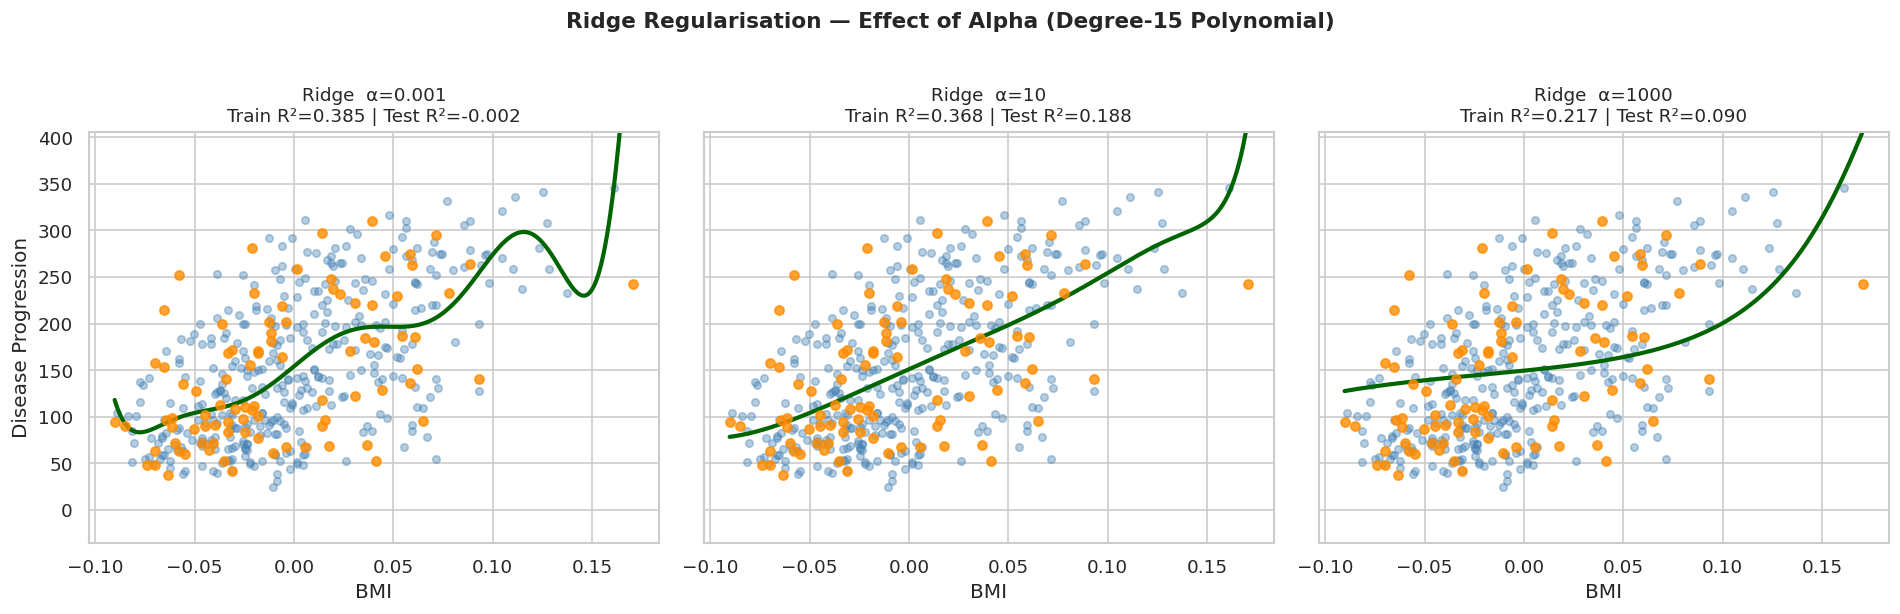

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, alpha in zip(axes, [0.001, 10, 1000]):
    pipe = make_ridge_pipeline(degree=15, alpha=alpha)
    pipe.fit(X_train, y_train)
    tr2 = pipe.score(X_train, y_train)
    te2 = pipe.score(X_test,  y_test)
    yp  = pipe.predict(X_plot)

    ax.scatter(X_train, y_train, alpha=0.4, color='steelblue',  s=20)
    ax.scatter(X_test,  y_test,  alpha=0.8, color='darkorange', s=30, zorder=5)
    ax.plot(X_plot, yp, color='darkgreen', linewidth=2.5)
    ax.set_ylim(y.min() - 60, y.max() + 60)
    ax.set_title(f'Ridge  α={alpha}\nTrain R²={tr2:.3f} | Test R²={te2:.3f}', fontsize=11)
    ax.set_xlabel('BMI')

axes[0].set_ylabel('Disease Progression')
plt.suptitle('Ridge Regularisation — Effect of Alpha (Degree-15 Polynomial)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 11. Validation Curve — Choosing the Best Hyperparameter

A **validation curve** sweeps over a hyperparameter (e.g., Ridge `alpha`) and  
plots cross-validated Train and Validation scores. It's the principled way to  
select hyperparameters without touching the test set.


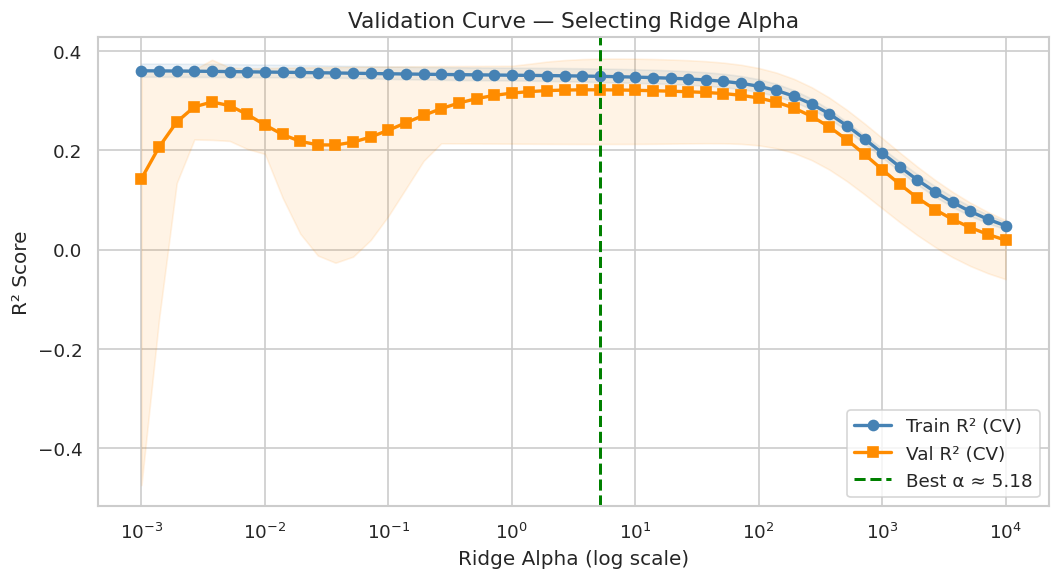

Best Ridge alpha (by CV validation R²): 5.1795


In [ ]:
from sklearn.model_selection import validation_curve

pipe_for_vc = Pipeline([
    ('poly',   PolynomialFeatures(degree=15, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  Ridge())
])

alphas_log = np.logspace(-3, 4, 50)
train_vc, val_vc = validation_curve(
    pipe_for_vc, X, y,
    param_name='model__alpha',
    param_range=alphas_log,
    cv=5, scoring='r2'
)

train_mean_vc = train_vc.mean(axis=1)
val_mean_vc   = val_vc.mean(axis=1)
best_alpha    = alphas_log[np.argmax(val_mean_vc)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(alphas_log, train_mean_vc, 'o-', color='steelblue',  label='Train R² (CV)', linewidth=2)
ax.semilogx(alphas_log, val_mean_vc,   's-', color='darkorange', label='Val R² (CV)',   linewidth=2)
ax.fill_between(alphas_log, train_vc.min(1), train_vc.max(1), alpha=0.1, color='steelblue')
ax.fill_between(alphas_log, val_vc.min(1),   val_vc.max(1),   alpha=0.1, color='darkorange')
ax.axvline(best_alpha, color='green', linestyle='--', linewidth=1.8,
           label=f'Best α ≈ {best_alpha:.2f}')
ax.set_xlabel('Ridge Alpha (log scale)', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Validation Curve — Selecting Ridge Alpha', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best Ridge alpha (by CV validation R²): {best_alpha:.4f}")

## 12. Bonus — Overfitting with Decision Trees

The same over/good/underfit story applies to any model.  
Here we vary `max_depth` of a **Decision Tree Regressor** on all features.


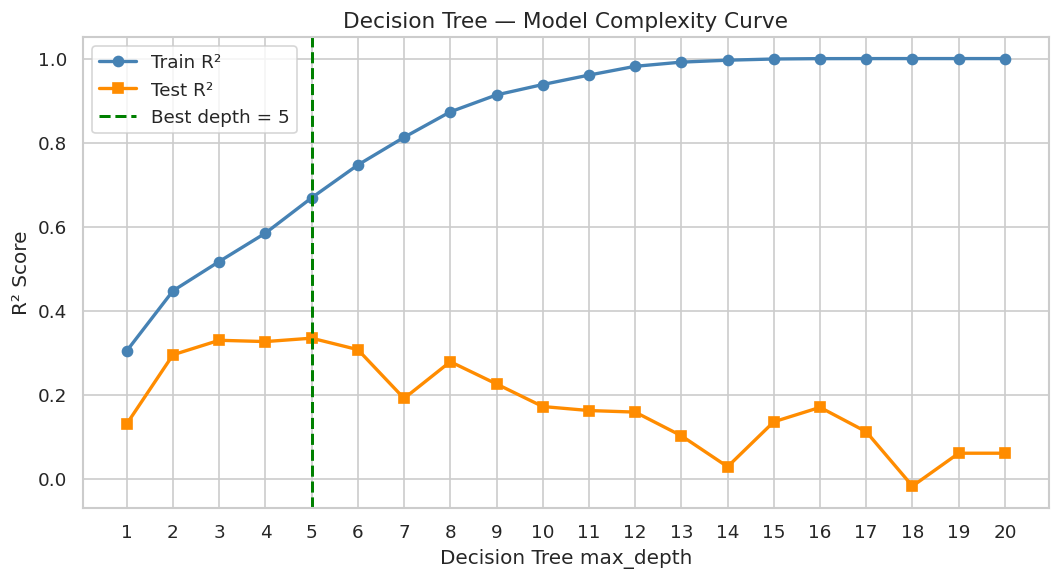

Best max_depth: 5  →  Test R² = 0.3345


In [ ]:
X_all = diabetes.data
y_all = diabetes.target

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

depths = range(1, 21)
dt_train, dt_test = [], []

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_tr, y_tr)
    dt_train.append(r2_score(y_tr, dt.predict(X_tr)))
    dt_test.append( r2_score(y_te, dt.predict(X_te)))

best_depth = depths[np.argmax(dt_test)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(depths), dt_train, 'o-', color='steelblue',  label='Train R²',  linewidth=2)
ax.plot(list(depths), dt_test,  's-', color='darkorange', label='Test R²',   linewidth=2)
ax.axvline(best_depth, color='green', linestyle='--', linewidth=1.8,
           label=f'Best depth = {best_depth}')
ax.set_xlabel('Decision Tree max_depth', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Decision Tree — Model Complexity Curve', fontsize=13)
ax.legend()
ax.set_xticks(list(depths))
plt.tight_layout()
plt.show()

print(f"Best max_depth: {best_depth}  →  Test R² = {max(dt_test):.4f}")


## 13. Summary & Key Takeaways

| Problem | Symptoms | Fixes |
|---|---|---|
| **Underfitting** | High Train error, High Test error | More complex model, add features, reduce regularisation |
| **Good Fit** | Low Train error ≈ Low Test error | ✅ Ship it |
| **Overfitting** | Very low Train error, High Test error | Regularisation (Ridge/Lasso), more data, simpler model, dropout |

### Diagnostic Toolkit
1. **Train vs Test error** — the primary check  
2. **Model Complexity Curve** — sweep complexity, find the minimum test error  
3. **Learning Curve** — does adding data help? (yes → high variance / overfitting)  
4. **Validation Curve** — choose the best regularisation hyperparameter via cross-validation

### Common Mistakes to Avoid ⚠️
- ❌ Evaluating a model **only on training data** — you will always see low error
- ❌ Choosing hyperparameters by looking at the **test set** — use cross-validation
- ❌ Concluding a model overfits from one feature's scatter plot (need train vs test comparison)
